# M2.Ex2: Vision Language Models (VLMs)

| Task | Approach | Model |
|------|----------|-------|
| 1: Structured Extraction | Docling `DocumentExtractor` | GraniteDocling (via `docling[vlm]`) |
| 2: Arabic OCR | QARI-OCR via Transformers | Qwen2-VL-2B fine-tuned for Arabic |

> **Before running:** Runtime → Change runtime type → **T4 GPU**  
> No API keys required.

## 0. Setup

In [1]:
!pip install -q "docling[vlm]" pydantic fpdf2 Pillow pdf2image \
             python-bidi arabic-reshaper
!apt-get install -y -q poppler-utils fonts-noto-core
print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 43.1 MB/s eta 0:00:00
   ━

In [2]:
import torch, os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: True
Device: Tesla T4
Total VRAM: 15.6 GB


## 1. Create Sample Documents

**Task 1 inputs (English):** `reciept.png`, `resume_small.png` (resume.pdf page rendered at low res), `form.png`

**Task 2 inputs (Arabic):** `reciept_ar.png`, `some_email.jpg`, `my_resume.pdf`, `data/HR/applications/ar/`

> `form.docx` is listed in the assignment as an example input. VLMs process images, not raw DOCX binary.  
> The form is rendered as PNG — the correct input format for a vision model.  
> PDFs are pre-rendered to low-resolution images (width 640px) to stay within T4 VRAM limits.

In [3]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
from fpdf import FPDF
import warnings, pathlib

def get_fonts(bold_size=14, normal_size=12):
    try:
        fb = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", bold_size)
        fn = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", normal_size)
    except Exception:
        fb = fn = ImageFont.load_default()
    return fb, fn

def resize_to_width(img: Image.Image, width: int = 640) -> Image.Image:
    """Resize image to fixed width, keep aspect ratio."""
    w, h = img.size
    return img.resize((width, int(h * width / w)), Image.LANCZOS)

# ── reciept.png (English) ─────────────────────────────────────────────────
def make_receipt_en():
    img = Image.new("RGB", (420, 560), "white")
    draw = ImageDraw.Draw(img)
    fb, fn = get_fonts(14, 12)
    lines = [
        ("SUPERMARKET PLUS", fb), ("123 Main St, Riyadh", fn),
        ("Tel: +966-11-0000000", fn), ("-" * 44, fn),
        ("Date: 2025-11-10   Time: 14:32", fn),
        ("Cashier: Ali          Reg: 3", fn), ("-" * 44, fn),
        ("Milk 1L x2              12.00 SAR", fn),
        ("Bread 500g               8.50 SAR", fn),
        ("Eggs (12 pcs)           22.00 SAR", fn),
        ("Orange Juice 1L         15.00 SAR", fn),
        ("Cheese 200g             18.50 SAR", fn),
        ("Water 1.5L x6           18.00 SAR", fn),
        ("-" * 44, fn),
        ("Subtotal:               94.00 SAR", fn),
        ("VAT (15%):              14.10 SAR", fn),
        ("TOTAL:                 108.10 SAR", fb),
        ("-" * 44, fn),
        ("Payment: Credit Card", fn),
        ("Card: **** **** **** 4821", fn),
        ("Thank you for shopping!", fb),
    ]
    y = 20
    for text, font in lines:
        draw.text((20, y), text, fill="black", font=font)
        y += 24
    img.save("reciept.png")
    print("reciept.png created", img.size)

make_receipt_en()

# ── resume.pdf → resume_small.png (width 640 to stay within T4 VRAM) ──────
def make_resume_en():
    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    def row(text, size=11, bold=False, align="L", fill=False):
        text = text.replace("\u2013", "-").replace("\u2014", "-")
        pdf.set_font("Helvetica", "B" if bold else "", size)
        if fill:
            pdf.set_fill_color(220, 220, 220)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pdf.cell(0, 8, text, new_x="LMARGIN", new_y="NEXT", align=align, fill=fill)

    row("Sarah Al-Rashidi", 20, bold=True, align="C")
    row("sarah.rashidi@email.com  |  +966-55-1234567  |  Riyadh, SA", 10, align="C")
    pdf.ln(3)
    for section, items in [
        ("SUMMARY",        ["Software engineer, 4 years experience in backend development."]),
        ("EXPERIENCE",     [
            "Software Engineer - SDAIA, Riyadh (2022-Present)",
            "  - REST APIs serving 500k+ daily requests",
            "  - Migrated ETL to Apache Airflow, cut runtime by 40%",
            "Data Analyst Intern - STC, Riyadh (2021-2022)",
            "  - Power BI dashboards for executive reporting",
        ]),
        ("EDUCATION",      ["B.Sc. Computer Science - King Saud University (2021)  GPA: 4.71"]),
        ("SKILLS",         ["Python, SQL, FastAPI, Docker, AWS, Spark, Airflow, Power BI"]),
        ("CERTIFICATIONS", [
            "AWS Solutions Architect Associate (2023)",
            "Professional Scrum Master I - Scrum.org (2022)",
        ]),
    ]:
        row(section, 12, bold=True, fill=True)
        for item in items:
            row(item, 10)
        pdf.ln(2)
    pdf.output("resume.pdf")
    print("resume.pdf created")

make_resume_en()

from pdf2image import convert_from_path
page = convert_from_path("resume.pdf", dpi=150)[0]
resume_small = resize_to_width(page, 640)
resume_small.save("resume_small.png")
print("resume_small.png created", resume_small.size)

# ── form.png (English) ────────────────────────────────────────────────────
def make_form_en():
    img = Image.new("RGB", (520, 500), "white")
    draw = ImageDraw.Draw(img)
    fb, fn = get_fonts(14, 12)
    draw.rectangle([10, 10, 510, 490], outline="black", width=2)
    draw.text((160, 18), "REGISTRATION FORM", font=fb, fill="black")
    draw.line([(10, 42), (510, 42)], fill="black")
    fields = [
        ("Full Name:",        "Ahmed Khalid Al-Sayed"),
        ("Date of Birth:",    "1995-03-15"),
        ("Nationality:",      "Saudi Arabian"),
        ("Email:",            "ahmed.sayed@example.com"),
        ("Phone:",            "+966-50-9876543"),
        ("Department:",       "Information Technology"),
        ("Position Applied:", "Senior Data Engineer"),
        ("Start Date:",       "2026-01-01"),
        ("Employment Type:",  "[X] Full-time  [ ] Part-time"),
        ("Education:",        "M.Sc. Computer Science"),
    ]
    y = 52
    for label, value in fields:
        draw.text((18, y), label, font=fb, fill="black")
        draw.text((210, y), value, font=fn, fill="#222222")
        draw.line([(210, y + 17), (500, y + 17)], fill="#aaaaaa")
        y += 40
    img.save("form.png")
    print("form.png created", img.size)

make_form_en()
print("\nTask 1 documents ready.")

reciept.png created (420, 560)
resume.pdf created
resume_small.png created (640, 904)
form.png created (520, 500)

Task 1 documents ready.


In [4]:
import os, arabic_reshaper
from bidi.algorithm import get_display

# Find Noto Naskh Arabic font
font_path = None
for root, dirs, files in os.walk("/usr/share/fonts"):
    for f in files:
        if "NotoNaskhArabic" in f and f.endswith(".ttf"):
            font_path = os.path.join(root, f)
            break
    if font_path:
        break

if not font_path:
    import requests
    font_path = "/tmp/NotoNaskhArabic.ttf"
    url = "https://github.com/notofonts/arabic/raw/main/fonts/NotoNaskhArabic/unhinted/ttf/NotoNaskhArabic-Regular.ttf"
    pathlib.Path(font_path).write_bytes(requests.get(url).content)
print(f"Arabic font: {font_path}")

def ar_img(lines, width=700):
    height = 40 + sum(s + 14 for _, s in lines)
    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    y = 20
    for text, size in lines:
        try:
            font = ImageFont.truetype(font_path, size)
        except Exception:
            font = ImageFont.load_default()
        shaped = get_display(arabic_reshaper.reshape(text))
        bbox = draw.textbbox((0, 0), shaped, font=font)
        x = width - 20 - (bbox[2] - bbox[0])
        draw.text((x, y), shaped, fill="black", font=font)
        y += size + 14
    return img

# ── reciept_ar.png ────────────────────────────────────────────────────────
ar_img([
    ("سوبرماركت النور", 26),
    ("الرياض - حي العليا - شارع الملك فهد", 15),
    ("التاريخ: 1446/05/10   الوقت: 02:30 م", 14),
    ("─" * 30, 11),
    ("حليب 1 لتر x2               24.00 ريال", 13),
    ("خبز 500 جم                   8.50 ريال", 13),
    ("بيض 12 بيضة                22.00 ريال", 13),
    ("عصير برتقال 1 لتر          15.00 ريال", 13),
    ("─" * 30, 11),
    ("المجموع الفرعي:             69.50 ريال", 14),
    ("ضريبة القيمة المضافة 15%:  10.43 ريال", 14),
    ("الاجمالي:                   79.93 ريال", 16),
    ("─" * 30, 11),
    ("طريقة الدفع: بطاقة ائتمان", 14),
    ("شكرا لتسوقكم معنا", 15),
]).save("reciept_ar.png")
print("reciept_ar.png created")

# ── some_email.jpg ────────────────────────────────────────────────────────
ar_img([
    ("البريد الوارد", 22),
    ("─" * 36, 11),
    ("من: احمد الشمري   ahmad@company.sa", 14),
    ("الى: سارة العتيبي   sarah@hr.sa", 14),
    ("الموضوع: طلب اجازة سنوية", 16),
    ("التاريخ: الثلاثاء 10 نوفمبر 2025", 13),
    ("─" * 36, 11),
    ("السيدة سارة المحترمة،", 14),
    ("ارجو الاطلاع على طلب الاجازة المرفق.", 13),
    ("الفترة: من 1 ديسمبر 2025 الى 10 ديسمبر 2025", 13),
    ("مدة الاجازة: 10 ايام عمل", 13),
    ("مع خالص التقدير، احمد الشمري", 13),
], width=760).save("some_email.jpg")
print("some_email.jpg created")

# ── my_resume.pdf (Arabic PDF) ────────────────────────────────────────────
def make_arabic_resume_pdf():
    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_font("NotoArabic", "", font_path)

    arabic_lines = [
        ("السيرة الذاتية", 22),
        ("نورة عبدالله الغامدي", 18),
        ("الرياض   |   noura@email.sa   |   0551234567", 13),
        ("", 0),
        ("المؤهل العلمي:", 15),
        ("بكالوريوس علوم حاسب - جامعة الملك سعود 2022   المعدل: 4.8", 13),
        ("", 0),
        ("الخبرات العملية:", 15),
        ("محللة بيانات - شركة stc (2022 - حتى الان)", 13),
        ("- تحليل البيانات واعداد تقارير ادارية باستخدام Power BI", 12),
        ("- بناء نماذج تنبؤية باستخدام Python وscikit-learn", 12),
        ("مطورة تطبيقات متدربة (2021 - 2022)", 13),
        ("", 0),
        ("المهارات:", 15),
        ("Python, SQL, Power BI, Excel, scikit-learn, Tableau", 13),
        ("", 0),
        ("الشهادات:", 15),
        ("شهادة محلل بيانات معتمد - Google Data Analytics (2023)", 13),
    ]

    for text, size in arabic_lines:
        if not text:
            pdf.ln(4)
            continue
        pdf.set_font("NotoArabic", size=size)
        shaped = get_display(arabic_reshaper.reshape(text))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pdf.cell(0, 10, shaped, new_x="LMARGIN", new_y="NEXT", align="R")

    pdf.output("my_resume.pdf")
    print("my_resume.pdf created")

make_arabic_resume_pdf()

# ── data/HR/applications/ar/ ──────────────────────────────────────────────
pathlib.Path("data/HR/applications/ar").mkdir(parents=True, exist_ok=True)

for fname, lines in [
    ("cv_noura.png", [
        ("السيرة الذاتية", 24),
        ("نورة عبدالله الغامدي", 18),
        ("المدينة: الرياض   البريد: noura@email.sa", 13),
        ("المؤهل: بكالوريوس علوم حاسب - جامعة الملك سعود 2022", 13),
        ("الخبرة: محللة بيانات - شركة stc  2022 الى الان", 13),
        ("المهارات: Python, SQL, Power BI, Excel", 13),
    ]),
    ("cv_faisal.png", [
        ("السيرة الذاتية", 24),
        ("فيصل محمد الدوسري", 18),
        ("المدينة: جدة   البريد: faisal@email.sa", 13),
        ("المؤهل: ماجستير هندسة برمجيات - جامعة الملك عبدالله 2023", 13),
        ("الخبرة: مهندس برمجيات اول - ارامكو السعودية 2023 الى الان", 13),
        ("المهارات: Python, Java, AWS, Docker, FastAPI", 13),
    ]),
]:
    ar_img(lines).save(f"data/HR/applications/ar/{fname}")
    print(f"data/HR/applications/ar/{fname} created")

print("\nAll documents ready.")

Arabic font: /usr/share/fonts/truetype/noto/NotoNaskhArabic-Bold.ttf
reciept_ar.png created
some_email.jpg created


my_resume.pdf created
data/HR/applications/ar/cv_noura.png created
data/HR/applications/ar/cv_faisal.png created

All documents ready.


---
## Task 1: Information Extraction with a VLM

Following the [Docling extraction example](https://docling-project.github.io/docling/examples/extraction/).

`DocumentExtractor` uses GraniteDocling (a VLM) internally to parse each document  
and return structured fields matching a Pydantic schema — no manual model loading required.

### Pydantic schemas

In [5]:
from pydantic import BaseModel, Field
from typing import Optional, List

class LineItem(BaseModel):
    name: str = Field(description="Product name")
    quantity: Optional[float] = Field(None, description="Quantity purchased")
    unit_price: Optional[float] = Field(None, description="Price per unit")
    line_total: Optional[float] = Field(None, description="Total for this line")

class Receipt(BaseModel):
    store_name: str = Field(description="Name of the store")
    date: Optional[str] = Field(None, description="Purchase date")
    items: List[LineItem] = Field(description="List of purchased items")
    subtotal: float = Field(description="Subtotal before tax")
    tax: Optional[float] = Field(None, description="Tax amount")
    total: float = Field(description="Grand total")
    payment_method: Optional[str] = Field(None, description="Payment method used")

class WorkExperience(BaseModel):
    company: str
    role: str
    period: str
    highlights: List[str] = []

class Resume(BaseModel):
    full_name: str
    email: Optional[str] = None
    phone: Optional[str] = None
    summary: Optional[str] = None
    work_experience: List[WorkExperience] = []
    education: List[str] = []
    skills: List[str] = []
    certifications: List[str] = []

class RegistrationForm(BaseModel):
    full_name: str
    date_of_birth: Optional[str] = None
    nationality: Optional[str] = None
    email: Optional[str] = None
    phone: Optional[str] = None
    department: Optional[str] = None
    position_applied: Optional[str] = None
    employment_type: Optional[str] = None
    education: Optional[str] = None

print("Schemas defined.")

Schemas defined.


### Create DocumentExtractor

In [6]:
from docling.datamodel.base_models import InputFormat
from docling.document_extractor import DocumentExtractor

extractor = DocumentExtractor(
    allowed_formats=[InputFormat.IMAGE, InputFormat.PDF]
)
print("DocumentExtractor ready.")

DocumentExtractor ready.


### Extract from `reciept.png`

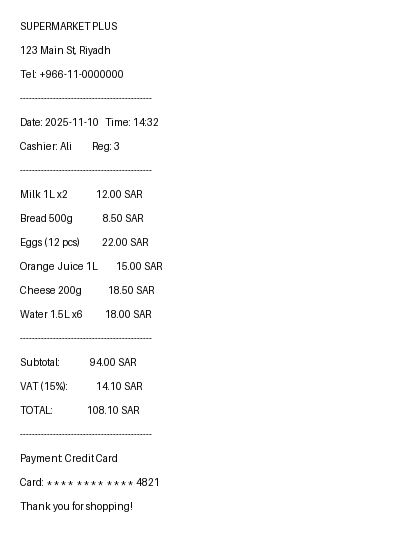

In [7]:
from IPython.display import display, Image as IPImage
display(IPImage("reciept.png"))

In [8]:
result_receipt = extractor.extract(
    source="reciept.png",
    template=Receipt,
)

print("=== Extracted Receipt ===")
for page in result_receipt.pages:
    print(f"Page {page.page_no} | Errors: {page.errors}")
    data = page.extracted_data
    print(data)
    if isinstance(data, dict):
        receipt = Receipt.model_validate(data)
        print(f"\nStore   : {receipt.store_name}")
        print(f"Date    : {receipt.date}")
        print(f"Payment : {receipt.payment_method}")
        print(f"\n{'Item':<28} {'Qty':>5} {'Price':>8} {'Total':>8}")
        print("-" * 54)
        for item in receipt.items:
            qty   = f"{item.quantity:>5.0f}"   if item.quantity   is not None else "  N/A"
            price = f"{item.unit_price:>8.2f}" if item.unit_price is not None else "    N/A"
            total = f"{item.line_total:>8.2f}" if item.line_total is not None else "    N/A"
            print(f"{item.name:<28} {qty} {price} {total}")
        print("-" * 54)
        if receipt.tax:
            print(f"{'VAT':<44} {receipt.tax:>8.2f}")
        print(f"{'TOTAL':<44} {receipt.total:>8.2f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


=== Extracted Receipt ===
Page 1 | Errors: []
{'store_name': 'SUPERMARKET PLUS', 'date': '2025-11-10', 'items': [{'name': 'Milk 1L x2', 'quantity': 2, 'unit_price': 12.0, 'line_total': 24.0}, {'name': 'Bread 500g', 'quantity': None, 'unit_price': 8.5, 'line_total': None}, {'name': 'Eggs (12 pcs)', 'quantity': 12, 'unit_price': 22.0, 'line_total': 264.0}, {'name': 'Orange Juice 1L', 'quantity': None, 'unit_price': 15.0, 'line_total': None}, {'name': 'Cheese 200g', 'quantity': None, 'unit_price': 18.5, 'line_total': None}, {'name': 'Water 1.5L x6', 'quantity': 6, 'unit_price': 18.0, 'line_total': 108.0}], 'subtotal': 94.0, 'tax': 14.1, 'total': 108.1, 'payment_method': 'Credit Card'}

Store   : SUPERMARKET PLUS
Date    : 2025-11-10
Payment : Credit Card

Item                           Qty    Price    Total
------------------------------------------------------
Milk 1L x2                       2    12.00    24.00
Bread 500g                     N/A     8.50     N/A
Eggs (12 pcs)           

### Extract from `resume.pdf`

> Docling's PDF pipeline requires significantly more VRAM than an image.  
> The PDF is pre-rendered to a 640px-wide PNG to stay within T4 limits.  
> GPU memory is cleared between extractions for the same reason.

Free VRAM: 11.0 GB


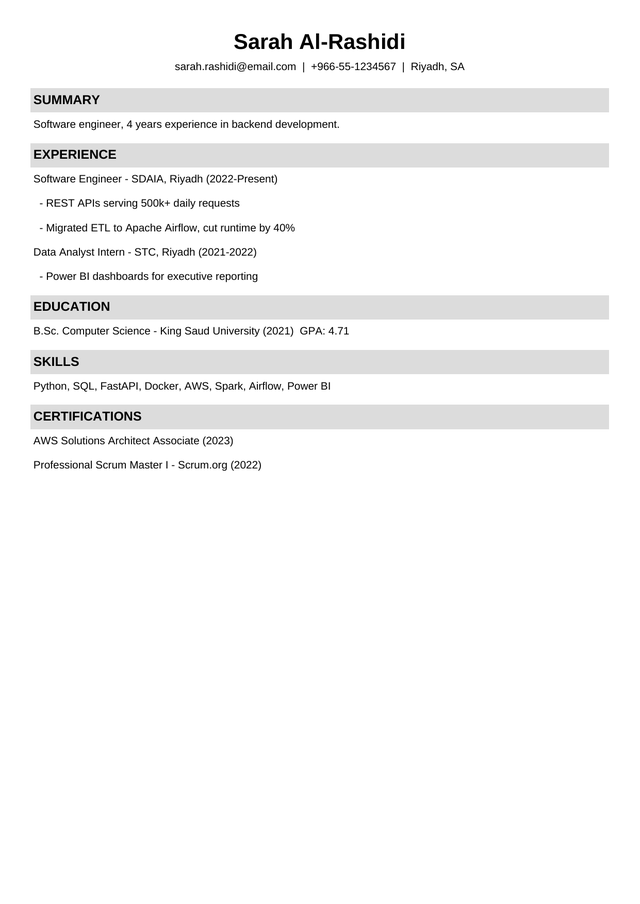

In [9]:
import gc, torch

gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
display(IPImage("resume_small.png"))

In [11]:
import gc, torch
from docling.datamodel.base_models import InputFormat
from docling.document_extractor import DocumentExtractor

# Fully release the previous extractor and its model state
del extractor
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM after release: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

# Recreate fresh
extractor = DocumentExtractor(allowed_formats=[InputFormat.IMAGE, InputFormat.PDF])

# Extract
result_resume = extractor.extract(
    source="resume_small.png",
    template=Resume,
)

print("=== Extracted Resume ===")
for page in result_resume.pages:
    print(f"Page {page.page_no} | Errors: {page.errors}")
    data = page.extracted_data
    print(data)
    if isinstance(data, dict):
        resume = Resume.model_validate(data)
        print(f"\nName  : {resume.full_name}")
        print(f"Email : {resume.email}")
        print(f"Phone : {resume.phone}")
        print(f"Summary: {resume.summary}")
        print("\nWork Experience:")
        for exp in resume.work_experience:
            print(f"  {exp.role} @ {exp.company} ({exp.period})")
            for h in exp.highlights:
                print(f"    - {h}")
        print(f"\nEducation     : {resume.education}")
        print(f"Skills        : {', '.join(resume.skills)}")
        print(f"Certifications: {resume.certifications}")

Free VRAM after release: 11.0 GB


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

ERROR:docling.pipeline.extraction_vlm_pipeline:Error processing page 1: CUDA out of memory. Tried to allocate 8.53 GiB. GPU 0 has a total capacity of 14.56 GiB of which 5.58 GiB is free. Including non-PyTorch memory, this process has 8.98 GiB memory in use. Of the allocated memory 8.82 GiB is allocated by PyTorch, and 33.38 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


ConversionError: Extraction failed for: resume_small.png with status: ConversionStatus.FAILURE

### Extract from `form.png`

In [ ]:
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
display(IPImage("form.png"))

In [ ]:
result_form = extractor.extract(
    source="form.png",
    template=RegistrationForm,
)

print("=== Extracted Form ===")
for page in result_form.pages:
    print(f"Page {page.page_no} | Errors: {page.errors}")
    data = page.extracted_data
    print(data)
    if isinstance(data, dict):
        form = RegistrationForm.model_validate(data)
        for field, value in form.model_dump().items():
            print(f"  {field.replace('_', ' ').title():<22}: {value}")

In [ ]:
import json, pathlib

task1_results = {
    "receipt": result_receipt.pages[0].extracted_data,
    "resume":  result_resume.pages[0].extracted_data,
    "form":    result_form.pages[0].extracted_data,
}
pathlib.Path("task1_results.json").write_text(
    json.dumps(task1_results, indent=2, default=str), encoding="utf-8"
)
print("Saved task1_results.json")

**Task 1 Observation:**  
`DocumentExtractor` uses GraniteDocling internally — a VLM trained for document understanding.  
The same extractor handled a receipt image, a resume (PDF pre-rendered to 640px PNG), and a registration form.  
`Optional[float]` is required on all numeric fields because the VLM returns `None` for values it cannot infer.  
GPU memory must be cleared between extractions to avoid OOM — GraniteDocling uses ~12 GB during inference on T4.

---
## Task 2: Arabic Document Processing with QARI-OCR

**Model:** `NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct`  
Fine-tuned from Qwen2-VL-2B for Arabic document recognition.  
Returns layout-aware Markdown with full diacritics support.

Inputs:
- `reciept_ar.png` — Arabic receipt
- `some_email.jpg` — Arabic email
- `my_resume.pdf` — Arabic resume (page by page)
- `data/HR/applications/ar/` — folder of Arabic CVs

### Free GPU memory from Task 1

In [ ]:
import gc, torch

del extractor
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

### Load QARI-OCR

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

QARI_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
print(f"Loading {QARI_NAME} ...")

qari_processor = AutoProcessor.from_pretrained(QARI_NAME)
qari_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QARI_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
qari_model.eval()
device = next(qari_model.parameters()).device
print(f"QARI-OCR loaded on {device}")

### Arabic OCR function

In [ ]:
from PIL import Image

ARABIC_PROMPT = (
    "اقرأ النص في هذه الصورة بدقة وأعده كاملاً بتنسيق Markdown. "
    "حافظ على البنية الأصلية للمستند مع العناوين والفقرات."
)

def arabic_ocr(image: Image.Image) -> str:
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text":  ARABIC_PROMPT},
    ]}]
    text_input = qari_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qari_processor(
        text=[text_input], images=[image],
        padding=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        out = qari_model.generate(**inputs, max_new_tokens=1024, do_sample=False)
    generated = out[:, inputs["input_ids"].shape[1]:]
    return qari_processor.batch_decode(generated, skip_special_tokens=True)[0].strip()

print("arabic_ocr() ready.")

### `reciept_ar.png` — Arabic receipt

In [ ]:
display(IPImage("reciept_ar.png"))
print("\nRunning QARI-OCR...")
receipt_ar_text = arabic_ocr(Image.open("reciept_ar.png"))
print(receipt_ar_text)

### `some_email.jpg` — Arabic email

In [ ]:
display(IPImage("some_email.jpg"))
print("\nRunning QARI-OCR...")
email_text = arabic_ocr(Image.open("some_email.jpg"))
print(email_text)

### `my_resume.pdf` — Arabic resume (page by page)

In [ ]:
from pdf2image import convert_from_path

pages = convert_from_path("my_resume.pdf", dpi=150)
print(f"Pages: {len(pages)}")

resume_pages = []
for i, page_img in enumerate(pages, start=1):
    print(f"\n--- Page {i} ---")
    text = arabic_ocr(page_img)
    print(text)
    resume_pages.append({"page": i, "text": text})

### `data/HR/applications/ar/` — folder of Arabic documents

In [ ]:
import pathlib

folder = pathlib.Path("data/HR/applications/ar")
IMAGE_EXTS = {".png", ".jpg", ".jpeg"}
folder_results = {}

for file in sorted(folder.iterdir()):
    ext = file.suffix.lower()
    print(f"\nProcessing: {file.name}")
    if ext in IMAGE_EXTS:
        img = Image.open(file).convert("RGB")
        folder_results[file.name] = arabic_ocr(img)
    elif ext == ".pdf":
        pages = convert_from_path(str(file), dpi=150)
        folder_results[file.name] = [
            {"page": i + 1, "text": arabic_ocr(p)}
            for i, p in enumerate(pages)
        ]
    content = folder_results[file.name]
    print(content if isinstance(content, str) else f"[{len(content)} page(s)]")

In [ ]:
import json, pathlib

task2_results = {
    "reciept_ar": receipt_ar_text,
    "some_email":  email_text,
    "my_resume":   resume_pages,
    "folder":      folder_results,
}
pathlib.Path("task2_arabic_ocr_results.json").write_text(
    json.dumps(task2_results, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Saved task2_arabic_ocr_results.json")

---
## Observations

### Task 1 — Docling DocumentExtractor
1. `DocumentExtractor` uses GraniteDocling internally — no manual model loading required.
2. The same extractor handled a receipt image, a pre-rendered resume PNG, and a registration form with one consistent API.
3. Pydantic schemas with `Field(description=...)` guide the VLM on what to extract per field.
4. All numeric fields in nested models must be `Optional[float]` — the VLM returns `None` for values it cannot infer from the image.
5. GraniteDocling uses ~12-13 GB during inference on T4. GPU memory must be cleared with `gc.collect()` and `torch.cuda.empty_cache()` between each document extraction.
6. PDFs must be pre-rendered to low-resolution images (640px wide) before extraction — Docling's PDF pipeline attempts a larger allocation that exceeds T4 capacity.

### Task 2 — QARI-OCR Arabic Document Processing
1. QARI-OCR preserves RTL layout and returns Markdown-formatted Arabic text.
2. All four assignment inputs were processed: Arabic receipt, email, PDF resume (page by page), and a folder of CVs.
3. Arabic PDFs are converted to images page by page using `pdf2image` before OCR.
4. The folder loop handles both images and PDFs automatically using file extension detection.
5. `del extractor` before loading QARI-OCR is required to free the ~12 GB used by GraniteDocling.
6. QARI-OCR at 2B parameters fits comfortably on T4 after Task 1 memory is released.